# Instagram Engagement Analysis
### Mini Data Science Project
**Research Question:** What factors drive higher engagement on Instagram posts?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [3]:
# Load the data
df = pd.read_csv('https://raw.githubusercontent.com/RajithmaHaseli/Instagram-Engagement-Analysis/main/Instagram_data.csv')

In [4]:
df.head()

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,8,5,21,5350,8503,0.0221,155,112,9,low


In [5]:
df.shape

(29999, 23)

In [6]:
# Remove unnecessary first columns: post_id, account_id, post_datetime — not needed for analysis
df = df.drop(columns=['post_id', 'account_id', 'post_datetime'])

In [13]:
# Standardize names: account_type, media_type, traffic_source — standardize those
df['media_type'] = df['media_type'].str.strip().str.lower()
df['traffic_source'] = df['traffic_source'].str.strip()
df['content_category'] = df['content_category'].str.strip()
df['performance_bucket_label'] = df['performance_bucket_label'].str.strip().str.lower()

In [8]:
#  Clean Item Names
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].str.strip()

In [9]:
# Handling Missing Values
numeric_cols = [c for c in [
    'follower_count', 'likes', 'comments', 'shares', 'saves',
    'reach', 'impressions', 'engagement_rate', 'followers_gained',
    'caption_length', 'hashtags_count', 'has_call_to_action'
] if c in df.columns]

# Replace any string NA with proper NaN
df[numeric_cols] = df[numeric_cols].replace('NA', pd.NA)

# Create cleaned copy
cleaned_df = df.copy()

# Check missing values
print("Missing values per column:")
print(cleaned_df.isnull().sum())

# Fill missing values with 0
cleaned_df.fillna(0, inplace=True)

# Check again
print("Missing values per column:")
print(cleaned_df.isnull().sum())

Missing values per column:
account_type                0
follower_count              0
media_type                  0
content_category            0
traffic_source              0
has_call_to_action          0
post_date                   0
post_hour                   0
day_of_week                 0
likes                       0
comments                    0
shares                      0
saves                       0
reach                       0
impressions                 0
engagement_rate             0
followers_gained            0
caption_length              0
hashtags_count              0
performance_bucket_label    0
dtype: int64
Missing values per column:
account_type                0
follower_count              0
media_type                  0
content_category            0
traffic_source              0
has_call_to_action          0
post_date                   0
post_hour                   0
day_of_week                 0
likes                       0
comments                    0
sha

In [10]:
# Convert to Numeric Type
cleaned_df[numeric_cols] = cleaned_df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [11]:
# Remove duplicates
print(f"\nDuplicate rows: {cleaned_df.duplicated().sum()}")
cleaned_df.drop_duplicates(inplace=True)
print(f"Duplicate rows: {cleaned_df.duplicated().sum()}")


Duplicate rows: 0
Duplicate rows: 0


In [12]:
cleaned_df.shape

(29999, 20)

In [14]:
# 1. Basic statistics
print("\nBasic statistics:")
print(cleaned_df[numeric_cols].describe())


Basic statistics:
       follower_count         likes      comments        shares         saves  \
count    29999.000000  29999.000000  29999.000000  29999.000000  29999.000000   
mean     10278.305477    287.653588      8.521917     14.426614     42.517284   
std       6691.862669    317.647682     10.116505     16.420899     47.808844   
min       3083.000000      0.000000      0.000000      0.000000      0.000000   
25%       5824.000000    104.000000      3.000000      5.000000     15.000000   
50%       9044.000000    199.000000      6.000000     10.000000     29.000000   
75%      10739.000000    363.000000     11.000000     19.000000     54.000000   
max      31095.000000  10632.000000    339.000000    516.000000   1542.000000   

              reach    impressions  engagement_rate  followers_gained  \
count  29999.000000   29999.000000     29999.000000      29999.000000   
mean    6272.475449    8466.952498         0.042107        502.152805   
std     4985.877059    6825.9003

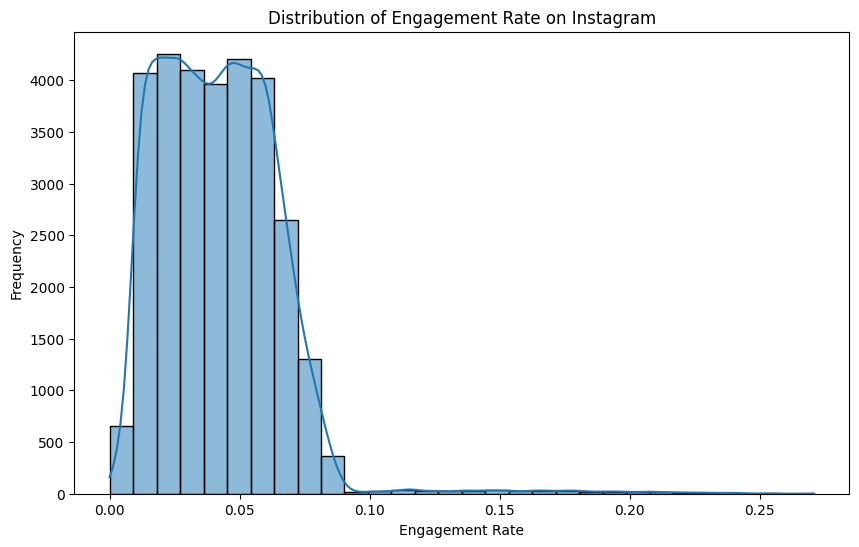

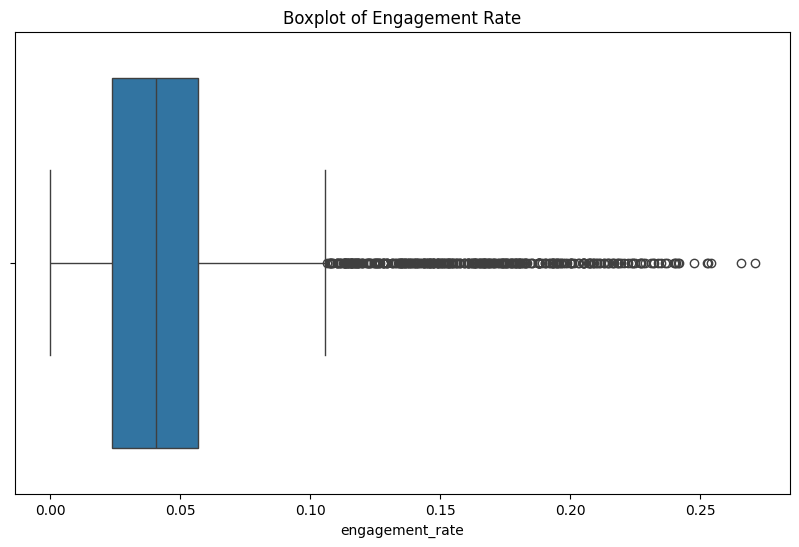

In [15]:
# Distribution of Engagement Rate
plt.figure(figsize=(10, 6))
sns.histplot(data=cleaned_df, x='engagement_rate', bins=30, kde=True)
plt.title("Distribution of Engagement Rate on Instagram")
plt.xlabel("Engagement Rate")
plt.ylabel("Frequency")
plt.show()

# Boxplot of Engagement Rate
plt.figure(figsize=(10, 6))
sns.boxplot(data=cleaned_df['engagement_rate'], orient='h')
plt.title("Boxplot of Engagement Rate")
plt.show()

media_type
carousel    0.041829
image       0.042256
reel        0.042266
Name: engagement_rate, dtype: float64


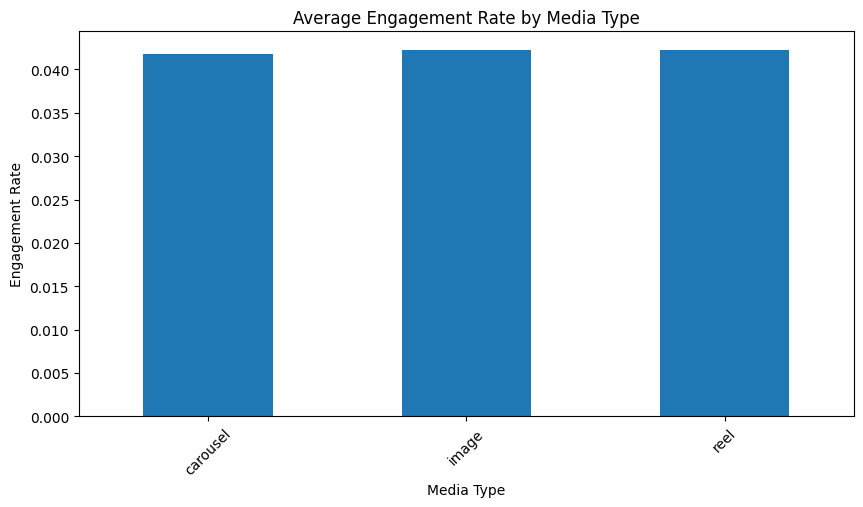

In [18]:
# Average Engagement Rate by Media Type
avg_eng = cleaned_df.groupby('media_type')['engagement_rate'].mean().sort_values()
print(avg_eng)

avg_eng.plot(kind='bar', figsize=(10, 5))
plt.title("Average Engagement Rate by Media Type")
plt.ylabel("Engagement Rate")
plt.xlabel("Media Type")
plt.xticks(rotation=45)
plt.show()

Eigenvalues (Explained Variance):
[5.20872019 1.29075931 0.99986087 0.242793   0.12460943 0.07870978
 0.04073401 0.01408008]
Total Variation: 8.0003


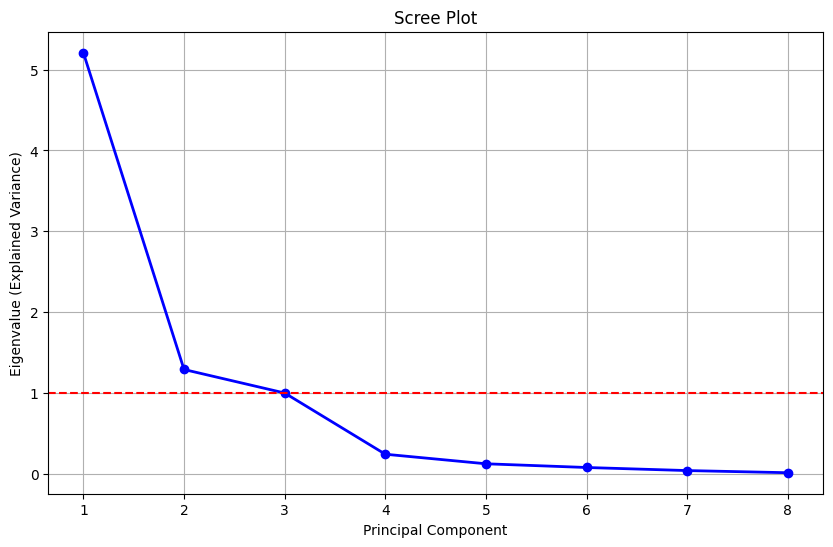


Proportion of Total Variation for Each Principal Component:
PC1: 0.6511 (65.11%)
PC2: 0.1613 (16.13%)
PC3: 0.1250 (12.50%)
PC4: 0.0303 (3.03%)
PC5: 0.0156 (1.56%)
PC6: 0.0098 (0.98%)
PC7: 0.0051 (0.51%)
PC8: 0.0018 (0.18%)

Cumulative Proportion of Total Variation:
PC1 to PC1: 0.6511 (65.11%)
PC1 to PC2: 0.8124 (81.24%)
PC1 to PC3: 0.9374 (93.74%)
PC1 to PC4: 0.9677 (96.77%)
PC1 to PC5: 0.9833 (98.33%)
PC1 to PC6: 0.9931 (99.31%)
PC1 to PC7: 0.9982 (99.82%)
PC1 to PC8: 1.0000 (100.00%)

Eigenvectors (Principal Components Loadings):

Principal Component 1:
follower_count    -0.001153
likes              0.425710
comments           0.406983
shares             0.417059
saves              0.418617
reach              0.369590
impressions        0.363532
engagement_rate    0.187626
dtype: float64

Principal Component 2:
follower_count    -0.024491
likes              0.117577
comments           0.108674
shares             0.106929
saves              0.108210
reach             -0.432026
impres

In [19]:
# Select Instagram numeric columns for PCA
instagram_cols = ['follower_count', 'likes', 'comments', 'shares',
                  'saves', 'reach', 'impressions', 'engagement_rate']
instagram_cols = [c for c in instagram_cols if c in cleaned_df.columns]

instagram_df = cleaned_df[instagram_cols]

scaler = StandardScaler()
instagram_scaled = scaler.fit_transform(instagram_df)

pca = PCA()
principal_components = pca.fit_transform(instagram_scaled)

eigenvalues = pca.explained_variance_
print("Eigenvalues (Explained Variance):")
print(eigenvalues)

total_variation = sum(eigenvalues)
print(f"Total Variation: {total_variation:.4f}")

# Scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'bo-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue (Explained Variance)')
plt.axhline(y=1, color='r', linestyle='--')
plt.grid()
plt.show()

# Proportion of variation
proportions = eigenvalues / total_variation
print("\nProportion of Total Variation for Each Principal Component:")
for i, prop in enumerate(proportions):
    print(f"PC{i+1}: {prop:.4f} ({prop*100:.2f}%)")

# Cumulative proportion
cumulative_prop = np.cumsum(proportions)
print("\nCumulative Proportion of Total Variation:")
for i, cum_prop in enumerate(cumulative_prop):
    print(f"PC1 to PC{i+1}: {cum_prop:.4f} ({cum_prop*100:.2f}%)")

# Eigenvectors
eigenvectors = pca.components_
print("\nEigenvectors (Principal Components Loadings):")
for i, component in enumerate(eigenvectors):
    print(f"\nPrincipal Component {i+1}:")
    print(pd.Series(component, index=instagram_cols))

media_type
image       11927
carousel    10627
reel         7445
Name: count, dtype: int64


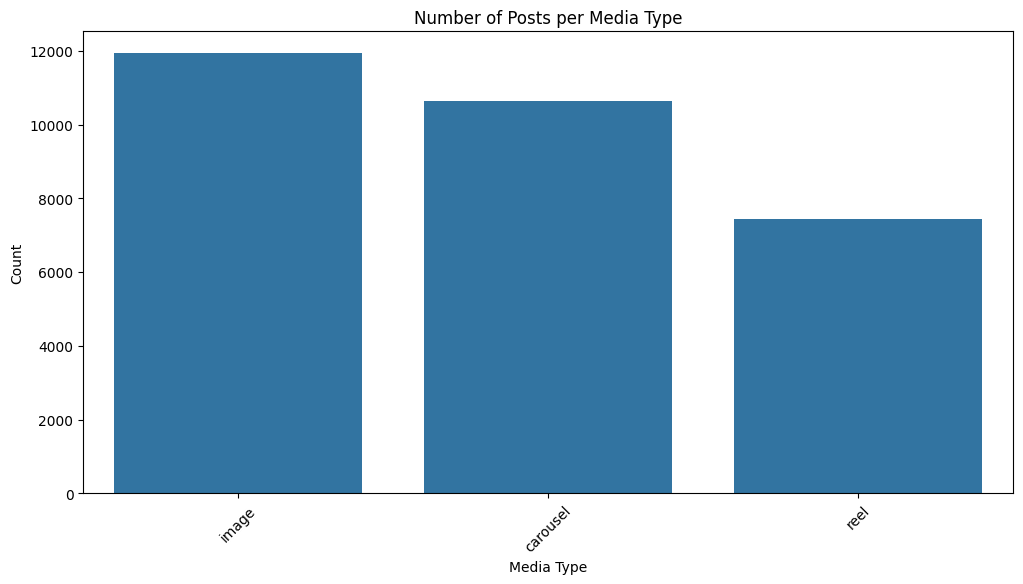

In [20]:
# Posts per Media Type
print(cleaned_df["media_type"].value_counts())
plt.figure(figsize=(12, 6))
sns.countplot(data=cleaned_df, x='media_type',
              order=cleaned_df['media_type'].value_counts().index)
plt.xticks(rotation=45)
plt.xlabel("Media Type")
plt.ylabel("Count")
plt.title("Number of Posts per Media Type")
plt.show()

                     likes      saves     shares
traffic_source                                  
Explore         284.252359  41.974354  14.145055
External        294.963437  43.645355  14.803397
Hashtags        286.408453  42.220620  14.409046
Home Feed       279.583547  41.358059  14.025843
Profile         291.913341  42.898428  14.601169
Reels Feed      288.860525  43.012137  14.574015


<Figure size 1200x600 with 0 Axes>

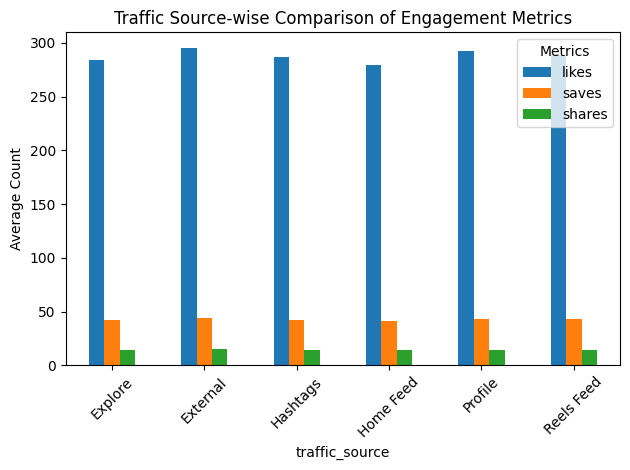

In [21]:
# Traffic Source Comparison
data = cleaned_df.copy()
traffic_stats = data.groupby('traffic_source')[['likes', 'saves', 'shares']].mean()
print(traffic_stats)
plt.figure(figsize=(12, 6))
traffic_stats.plot(kind='bar', stacked=False)
plt.title('Traffic Source-wise Comparison of Engagement Metrics')
plt.ylabel('Average Count')
plt.xticks(rotation=45)
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

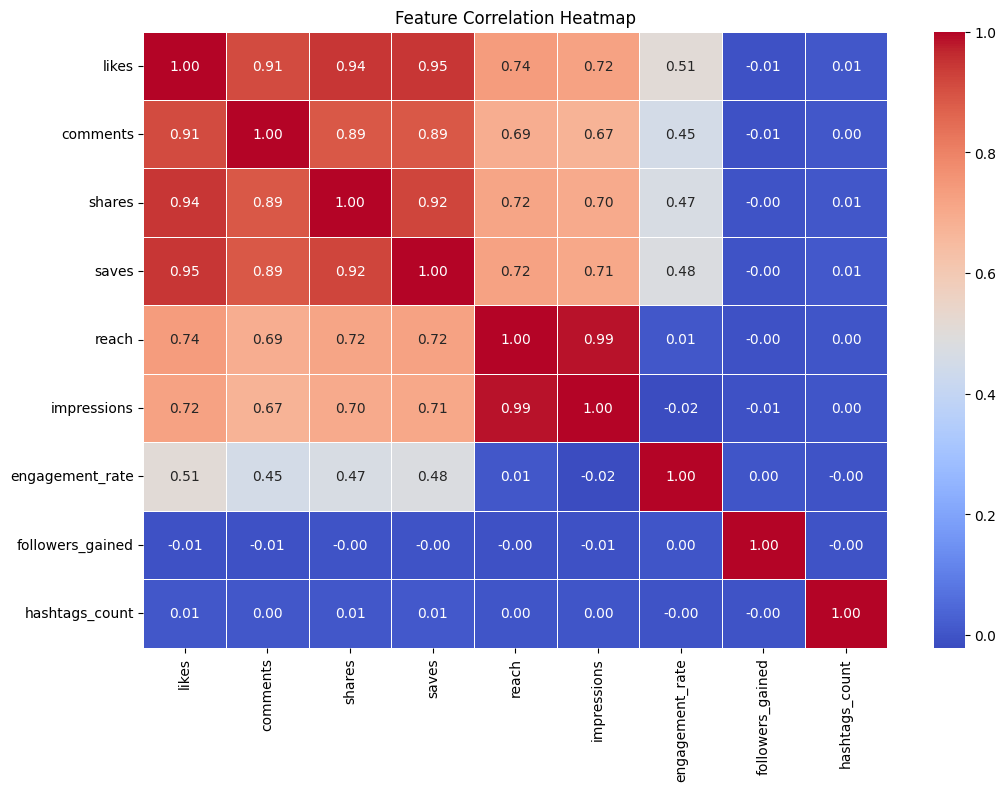

In [23]:
# Correlation Heatmap
corr_cols = [c for c in ['likes', 'comments', 'shares', 'saves',
             'reach', 'impressions', 'engagement_rate',
             'followers_gained', 'hashtags_count'] if c in cleaned_df.columns]
plt.figure(figsize=(12, 8))
sns.heatmap(cleaned_df[corr_cols].corr(), annot=True,
            cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

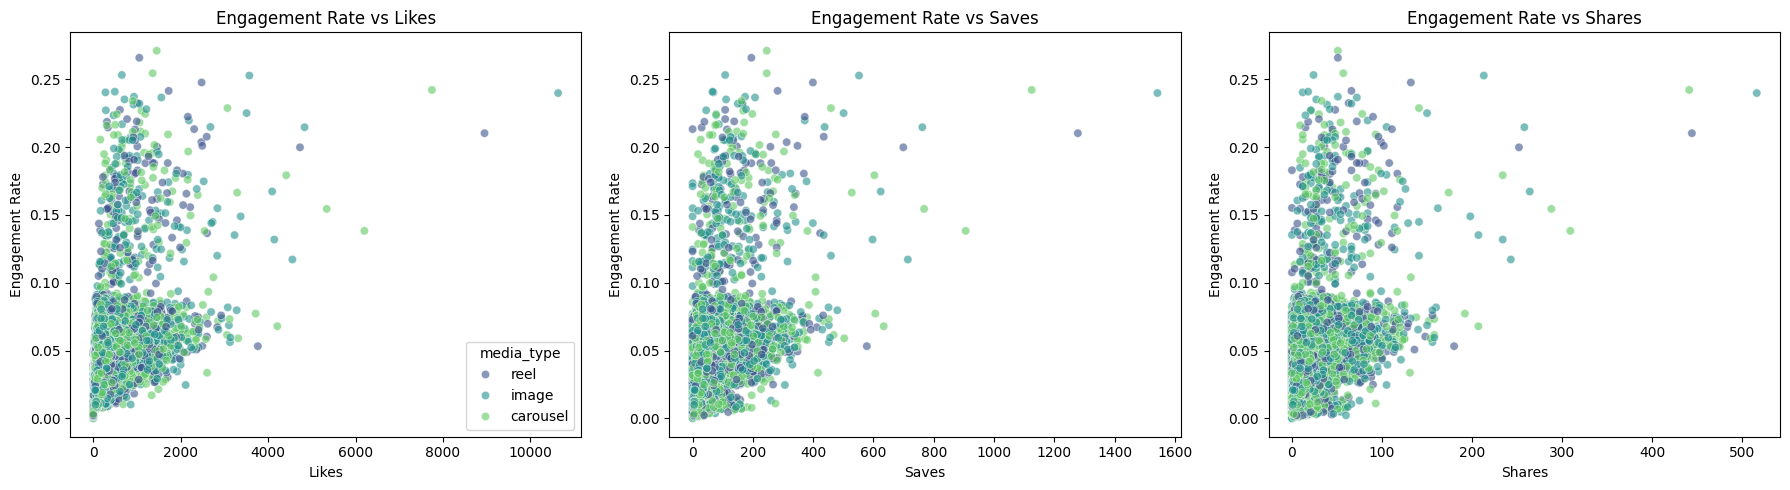

In [24]:
# Scatter Plots
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='likes', y='engagement_rate', data=cleaned_df,
                hue='media_type', palette='viridis', alpha=0.6)
plt.title('Engagement Rate vs Likes')
plt.xlabel('Likes')
plt.ylabel('Engagement Rate')

plt.subplot(1, 3, 2)
sns.scatterplot(x='saves', y='engagement_rate', data=cleaned_df,
                hue='media_type', palette='viridis', alpha=0.6)
plt.title('Engagement Rate vs Saves')
plt.xlabel('Saves')
plt.ylabel('Engagement Rate')
plt.legend().remove()

plt.subplot(1, 3, 3)
sns.scatterplot(x='shares', y='engagement_rate', data=cleaned_df,
                hue='media_type', palette='viridis', alpha=0.6)
plt.title('Engagement Rate vs Shares')
plt.xlabel('Shares')
plt.ylabel('Engagement Rate')
plt.legend().remove()

plt.tight_layout()
plt.show()